# 02 — Базовые модели (Baselines)

**Проект:** ML-генератор торговых сигналов (Algorithmic Trading Signal Predictor).

**Цель ноутбука:** настроить систему трекинга экспериментов MLflow, реализовать честное хронологическое разбиение данных (Time-based split) без утечек информации и построить базовые модели (Dummy и Логистическую регрессию).

**Данные:** обработанный датасет `data/trading_data.csv`.

In [1]:
import os
import sys
from pathlib import Path
import random

if Path.cwd().name == 'notebooks':
    os.chdir('..')

PROJECT_DIR = Path.cwd()
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import mlflow

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

DATA_DIR = PROJECT_DIR / "data"
ART_DIR = PROJECT_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"

pd.set_option("display.max_columns", None)

C:\Users\Redmi\AppData\Roaming\Python\Python39\site-packages\mlflow\protos\service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


## 1. Загрузка данных и выделение признаков

Чтобы гарантированно избежать Target Leak, мы явно выбираем только сгенерированные нами технические индикаторы.

In [2]:
data_path = DATA_DIR / "trading_data.csv"
df = pd.read_csv(data_path)

FEATURES = ['sma_7', 'sma_30', 'volatility', 'momentum_3d']
TARGET = 'target'

X = df[FEATURES]
y = df[TARGET]

print("Матрица признаков X:", X.shape)
X.head()

Матрица признаков X: (971, 4)


,sma_7,sma_30,volatility,momentum_3d
0,28666.198571,27469.847667,0.030848,0.056137
1,29071.671429,27583.591667,0.020328,0.044534
2,29724.415714,27800.059333,0.161984,0.114630
3,30513.961429,28055.871000,0.074015,0.134168
4,31396.254286,28328.912333,0.042856,0.150157


## 2. Валидация: Time-based Split (Хронологическое разбиение)

Для данных с временной зависимостью случайное перемешивание категорически запрещено. Используем `shuffle=False` для разделения на Train и Test.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

print(f"Обучающая выборка (прошлое): {X_train.shape[0]} строк")
print(f"Тестовая выборка (будущее): {X_test.shape[0]} строк")

Обучающая выборка (прошлое): 728 строк
Тестовая выборка (будущее): 243 строк


## 3. Настройка локального MLflow трекинга

In [ ]:
tracking_uri = (PROJECT_DIR / "mlruns").resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("Trading_Signals_Baselines")

2026/06/17 20:37:25 INFO mlflow.tracking.fluent: Experiment with name 'Trading_Signals_Baselines' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///D:/AIE_1/project/mlruns/943369318931004743', creation_time=1781717845984, experiment_id='943369318931004743', last_update_time=1781717845984, lifecycle_stage='active', name='Trading_Signals_Baselines', tags={}>

## 4. Эксперимент 1: Dummy Classifier (Наивный Baseline)

Строим простейшую модель, которая всегда предсказывает наиболее частый класс, чтобы зафиксировать точку отсчета.

In [5]:
with mlflow.start_run(run_name="Dummy_Baseline"):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    
    acc_dummy = accuracy_score(y_test, y_pred_dummy)
    
    mlflow.log_param("model_type", "Dummy")
    mlflow.log_metric("accuracy", acc_dummy)
    print(f"[Dummy Baseline] Accuracy: {acc_dummy:.4f}")

[Dummy Baseline] Accuracy: 0.4650


## 5. Эксперимент 2: Logistic Regression (Линейный Baseline)

Классическая логистическая регрессия. Признаки обязательно оборачиваем в `StandardScaler` внутри пайплайна.

[LogReg Baseline] Accuracy: 0.5062
[LogReg Baseline] Precision (Важно для трейдинга): 0.4822
[LogReg Baseline] ROC-AUC: 0.4809


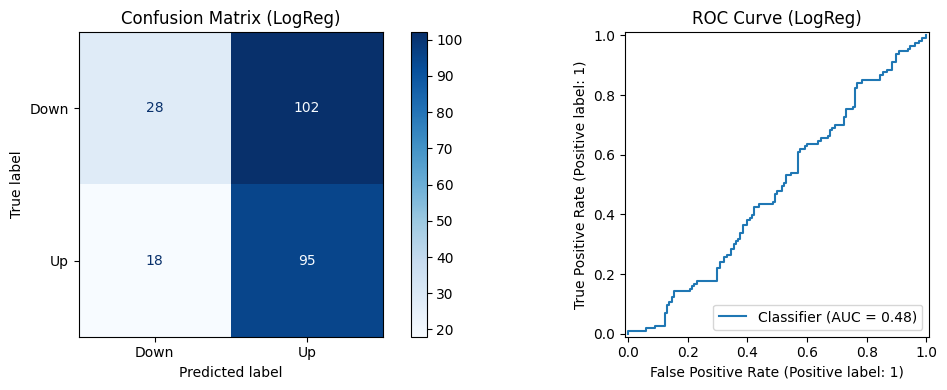

In [6]:
with mlflow.start_run(run_name="Logistic_Regression"):
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42))
    ])
    
    pipe_lr.fit(X_train, y_train)
    y_pred_lr = pipe_lr.predict(X_test)
    y_probs_lr = pipe_lr.predict_proba(X_test)[:, 1]
    
    # Расчет метрик
    acc = accuracy_score(y_test, y_pred_lr)
    prec = precision_score(y_test, y_pred_lr, zero_division=0)
    f1 = f1_score(y_test, y_pred_lr, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_probs_lr)
    
    # Логирование параметров и метрик в MLflow
    mlflow.log_params({"model": "LogisticRegression", "scaler": "StandardScaler"})
    mlflow.log_metrics({"accuracy": acc, "precision": prec, "f1_score": f1, "roc_auc": roc_auc})
    
    print(f"[LogReg Baseline] Accuracy: {acc:.4f}")
    print(f"[LogReg Baseline] Precision (Важно для трейдинга): {prec:.4f}")
    print(f"[LogReg Baseline] ROC-AUC: {roc_auc:.4f}")
    
    # Визуализация результатов
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax[0], cmap='Blues', display_labels=['Down', 'Up'])
    ax[0].set_title("Confusion Matrix (LogReg)")
    ax[0].grid(False)
    
    RocCurveDisplay.from_predictions(y_test, y_probs_lr, ax=ax[1])
    ax[1].set_title("ROC Curve (LogReg)")
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "baseline_evaluation.png")
    plt.show()

## 6. Выводы по разделу Baselines

1. **Валидация настроена:** Данные разделены строго хронологически, что исключает Data Leaks.
2. **Результаты линейной модели:** Логистическая регрессия показала результат на уровне случайного угадывания (Accuracy ~50.6%, ROC-AUC 0.48). Главная проблема — алгоритм выдает слишком много ложных сигналов на покупку (102 False Positives), из-за чего ключевая метрика Precision упала до ~48.2%. Для реального трейдинга такой алгоритм убыточен.
3. **Следующий шаг:** Мы доказали, что рыночные паттерны имеют сложную нелинейную природу, с которой базовые модели не справляются. В ноутбуке `03_models_tuning.ipynb` мы применим мощный нелинейный алгоритм (Random Forest) и оценим стабильность его метрик с помощью метода Bootstrap.